In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,f1_score,roc_auc_score,confusion_matrix,roc_curve
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
import warnings
import  xgboost as xgb
warnings.filterwarnings("ignore")

In [74]:
df=pd.read_csv("dataset/processed/feature_data.csv")

In [75]:
df.shape

(180516, 33)

## Data Preparation

Features rebuilt from clean_data.csv and train/test split applied.
80/20 split with stratify=y ensures both sets have the same class distribution.
Total features going into the model: shown above in X_train shape.

In [76]:
# After analysing the columns it seems some of the columns will cause data leak so we will be removeing them
leaky=['delay_gap','Days for shipping (real)', 
         'Days for shipment (scheduled)', 'Order_processing_days']
df.drop(columns=leaky,inplace=True)

# Chronological split
split_index=int(len(df)*0.8)
train_df=df[split_index:]
test_df=df[:split_index]

x_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
x_test = test_df.drop(columns=['Late_delivery_risk'])
y_test = test_df['Late_delivery_risk']

print("X train :",x_train.shape)
print("X test :",x_test.shape)
print(f"Train Late Rate :{y_train.mean():.3f}")
print(f"Test Late Rate : {y_test.mean():.3f}")

X train : (36104, 28)
X test : (144412, 28)
Train Late Rate :0.547
Test Late Rate : 0.549


## Baseline: Logistic Regression

Logistic regression serves as our baseline. StandardScaler applied
since logistic regression is sensitive to feature scale.
class_weight='balanced' handles the class imbalance automatically.

This gives us a performance floor  any model we build must beat this.

In [77]:
# Building a Base Line Model
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(x_train_scaled, y_train)
lr_preds = lr.predict(x_test_scaled)
lr_proba = lr.predict_proba(x_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print(f"AUC-ROC: {roc_auc_score(y_test, lr_proba):.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.73      0.78      0.76     65171
           1       0.81      0.76      0.79     79241

    accuracy                           0.77    144412
   macro avg       0.77      0.77      0.77    144412
weighted avg       0.78      0.77      0.77    144412

AUC-ROC: 0.8614


## Main Model: XGBoost Classifier

XGBoost is our primary model. Key parameters:
- n_estimators=200: number of trees
- max_depth=6: controls overfitting
- learning_rate=0.1: step size per tree
- subsample + colsample_bytree=0.8: random sampling for robustness

No scaling needed tree based models are scale invariant.

In [79]:
xgb_model=xgb.XGBClassifier( n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42)
xgb_model.fit(x_train,y_train)
xgb_preds=xgb_model.predict(x_test)
xgb_proba = xgb_model.predict_proba(x_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))
print(f"AUC-ROC: {roc_auc_score(y_test,xgb_proba):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.74      0.77      0.75     65171
           1       0.80      0.78      0.79     79241

    accuracy                           0.77    144412
   macro avg       0.77      0.77      0.77    144412
weighted avg       0.77      0.77      0.77    144412

AUC-ROC: 0.8716


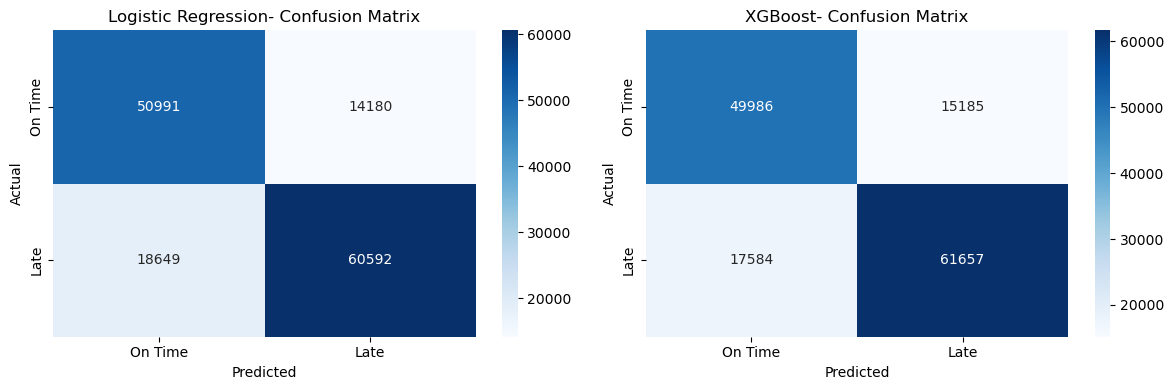

In [89]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

for ax,pred,title in zip(axes,[lr_preds,xgb_preds],['Logistic Regression',"XGBoost"]):
    cm=confusion_matrix(y_test,pred)
    sns.heatmap(cm,annot=True,cmap="Blues",ax=ax,fmt="d",xticklabels=['On Time',"Late"],yticklabels=['On Time','Late'])
    ax.set_title(f"{title}- Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
os.makedirs("reports/figures", exist_ok=True)
plt.savefig("reports/figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

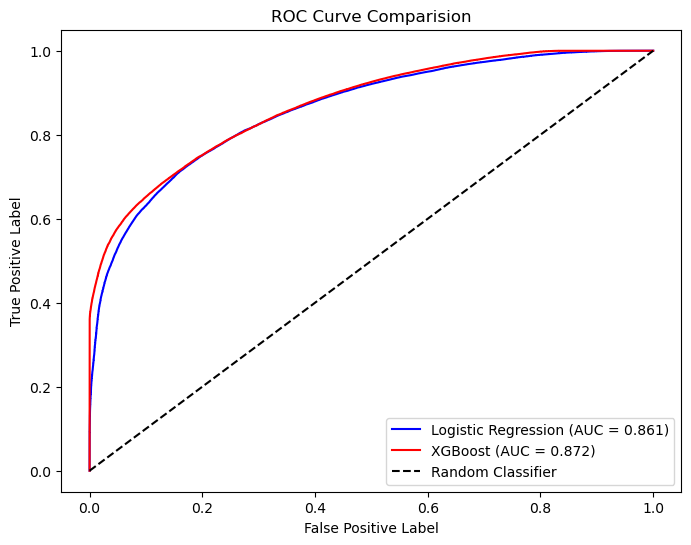

In [91]:
fig,ax=plt.subplots(figsize=(8,6))

for probs,label,color in zip([lr_proba,xgb_proba],["Logistic Regression","XGBoost"],['blue','red']):
    fpr,tpr,_=roc_curve(y_test,probs)
    auc=roc_auc_score(y_test,probs)
    ax.plot(fpr,tpr,label=f"{label} (AUC = {auc:.3f})",color=color)
ax.plot([0,1],[0,1],'k--',label='Random Classifier')
ax.set_xlabel("False Positive Label")
ax.set_ylabel("True Positive Label")
ax.set_title("ROC Curve Comparision")
ax.legend()
plt.savefig("reports/figures/roc_curve.png",dpi=150,bbox_inches="tight")
plt.show()

## ROC Curve Comparison

AUC-ROC measures the model's ability to distinguish between late and
on-time shipments across all classification thresholds.

AUC = 1.0 is perfect. AUC = 0.5 is random guessing.


In [92]:
xgb_model.feature_importances_

array([0.01089341, 0.01032663, 0.01744754, 0.01678261, 0.01070293,
       0.00937453, 0.01092238, 0.01054551, 0.00829596, 0.01019805,
       0.00983363, 0.01049366, 0.00991809, 0.        , 0.        ,
       0.01448578, 0.20279066, 0.02622939, 0.23002176, 0.04688534,
       0.01154704, 0.02085511, 0.01736756, 0.01618221, 0.00947104,
       0.16123293, 0.02142246, 0.07577381], dtype=float32)

In [93]:
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                   Feature  Importance
18      customer_late_rate    0.230022
16      Shipping_mode_risk    0.202791
25   Shipping Mode_encoded    0.161233
27    Order Status_encoded    0.075774
19  customer_avg_delay_gap    0.046885
17   customer_total_orders    0.026229
26            Type_encoded    0.021422
21          Market_encoded    0.020855
2                 Latitude    0.017448
22    Order Region_encoded    0.017368
